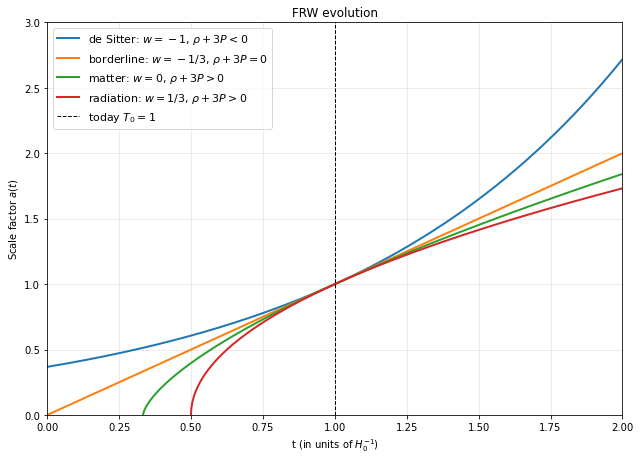

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def rhs_acceleration(T, y, w):
    """
    y[0] = a
    y[1] = da/dT
    """
    a, adot = y #initial conditions

    if a <= 0:
        return [adot, 0.0]

    addot = -0.5 * (1.0 + 3.0*w) * a**(-2.0 - 3.0*w) #ddot{a} = k(1+3w)a^{-2-3w}

    return [adot, addot]


def hit_small_a(T, y, w):
    """
    Stop integration when a gets very close to zero.
    """
    return y[0] - 1e-4

hit_small_a.terminal = True
hit_small_a.direction = -1


cases = {
    r"de Sitter: $w=-1$, $\rho+3P<0$": -1.0,
    #r"general: $w=-2/3$, $\rho+3P<0$": -2.0/3.0,
    r"borderline: $w=-1/3$, $\rho+3P=0$": -1.0/3.0,
    r"matter: $w=0$, $\rho+3P>0$": 0.0,
    r"radiation: $w=1/3$, $\rho+3P>0$": 1.0/3.0,
}

T0 = 1.0 #present time
T_min = 0.0 #big bang
T_max = 2.0

plt.figure(figsize=(9, 6.5))

for label, w in cases.items():

    # Integrate backward from today T0 to T=0
    sol_back = solve_ivp(
        fun=lambda T, y: rhs_acceleration(T, y, w),
        t_span=(T0, T_min),
        y0=[1.0, 1.0],
        events=lambda T, y: hit_small_a(T, y, w),
        max_step=0.002,
        rtol=1e-9,
        atol=1e-11
    )

    # Integrate forward from today
    sol_forw = solve_ivp(
        fun=lambda T, y: rhs_acceleration(T, y, w),
        t_span=(T0, T_max),
        y0=[1.0, 1.0],
        max_step=0.002,
        rtol=1e-9,
        atol=1e-11
    )

    T_vals = np.concatenate((sol_back.t[::-1], sol_forw.t[1:]))
    a_vals = np.concatenate((sol_back.y[0][::-1], sol_forw.y[0][1:]))

    plt.plot(T_vals, a_vals, lw=2, label=label)

plt.axvline(T0, color="black", linestyle="--", linewidth=1, label=r"today $T_0=1$")


plt.xlabel(r"t (in units of $H_{0}^{-1}$)")
plt.ylabel(r"Scale factor $a(t)$")
plt.title(r"FRW evolution")
plt.xlim(T_min, T_max)
plt.ylim(0, 3)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()